# One claim hedges one direction

The Brownian model has two shocks: productivity and automation. A holding of one risky claim scales one fixed payoff vector across those shocks. It can therefore remove the part of fiscal exposure that lies along that vector, but no quantity of the same claim can remove an orthogonal component.

The rank and projection calculations below are exact linear algebra. The vector values are illustrative, and the notebook does not attach a welfare magnitude to completing the span.

## The payoff space in components

Let the first claim load by $\lambda_z$ on the productivity innovation and by $\lambda_x$ on the automation innovation:

$$
\lambda=
\begin{pmatrix}
\lambda_z\\
\lambda_x
\end{pmatrix}.
$$

A public holding $s$ produces the exposure $s\lambda$. Varying $s$ traces a line, not the full two-dimensional shock space. An orthogonal payoff direction is

$$
\eta=
\begin{pmatrix}
-\lambda_x\\
\lambda_z
\end{pmatrix},
\qquad
\lambda^\top\eta=0.
$$

Thus the one-claim menu $\Sigma_1=[\lambda]$ has rank one, while $\Sigma_2=[\lambda,\eta]$ has rank two whenever $\lambda\ne0$. Under the maintained normalization, the second claim earns no excess return from the world price of risk because its loading is orthogonal to $\lambda$; its contribution is insurance span.

## Decomposing fiscal exposure

Call the government's worker-relevant exposure $\zeta$. The next cell splits it into a projection on the first claim and a residual:

$$
\zeta
=
\underbrace{\frac{\zeta^\top\lambda}{\lambda^\top\lambda}\lambda}_{\text{reachable with the first claim}}
+
\underbrace{\zeta^\perp}_{\text{left unspanned}},
\qquad
(\zeta^\perp)^\top\lambda=0.
$$

The Euclidean projection is appropriate here because the illustrative Brownian coordinates are normalized and uncorrelated.

In [1]:
import numpy as np
from IPython.display import Markdown, display

lam = np.array([0.8, 0.6])
rotation = np.array([[0.0, -1.0], [1.0, 0.0]])
eta = rotation @ lam
fiscal_exposure = np.array([-0.2, 1.0])

reachable = (fiscal_exposure @ lam) / (lam @ lam) * lam
unspanned = fiscal_exposure - reachable
sigma_one = lam.reshape(2, 1)
sigma_two = np.column_stack([lam, eta])

lines = [
    "| Check | Value |",
    "|---|---:|",
    f"| payoff-space dimension with one claim | {np.linalg.matrix_rank(sigma_one)} |",
    f"| payoff-space dimension with two independent claims | {np.linalg.matrix_rank(sigma_two)} |",
    f"| inner product of the two claim loadings | {lam @ eta:.3g} |",
    f"| size of total fiscal exposure | {np.linalg.norm(fiscal_exposure):.3f} |",
    f"| size reachable with the first claim | {np.linalg.norm(reachable):.3f} |",
    f"| size left unspanned | {np.linalg.norm(unspanned):.3f} |",
    f"| projection reconstruction error | {np.linalg.norm(fiscal_exposure-reachable-unspanned):.2e} |",
    f"| residual exposure to the first claim | {abs(unspanned @ lam):.2e} |",
]
display(Markdown("\n".join(lines)))

| Check | Value |
|---|---:|
| payoff-space dimension with one claim | 1 |
| payoff-space dimension with two independent claims | 2 |
| inner product of the two claim loadings | 0 |
| size of total fiscal exposure | 1.020 |
| size reachable with the first claim | 0.440 |
| size left unspanned | 0.920 |
| projection reconstruction error | 0.00e+00 |
| residual exposure to the first claim | 5.55e-17 |

## Seeing the missing direction

The black arrow is the fiscal exposure. In the left panel, the blue line is everything attainable by changing the holding of the first claim; the red arrow is what remains. The green line in the right panel adds an independent payoff and completes this two-shock financial span.

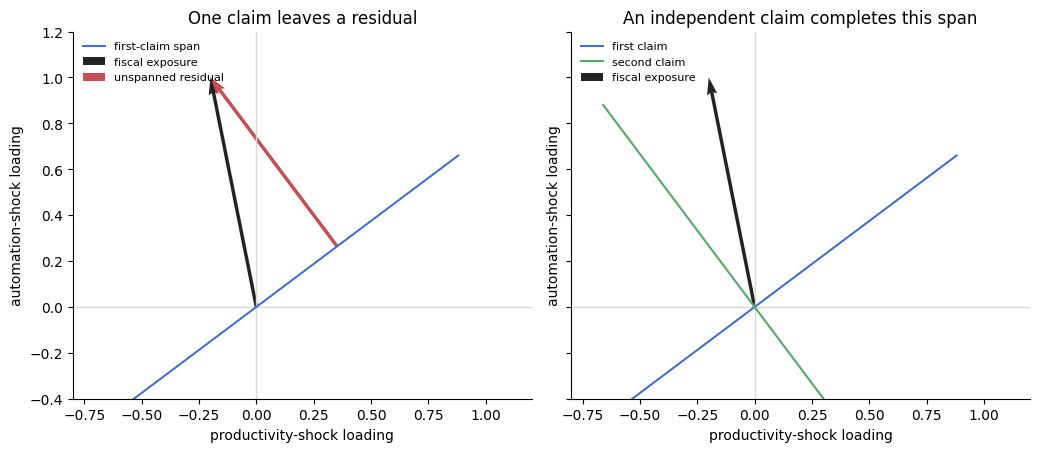

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), sharex=True, sharey=True)
for ax in axes:
    ax.axhline(0, color="0.85", linewidth=1)
    ax.axvline(0, color="0.85", linewidth=1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-0.8, 1.2)
    ax.set_ylim(-0.4, 1.2)
    ax.set_xlabel("productivity-shock loading")
    ax.set_ylabel("automation-shock loading")
    ax.spines[["top", "right"]].set_visible(False)

scale = np.linspace(-1.1, 1.1, 50)
axes[0].plot(scale * lam[0], scale * lam[1], color="#4472C4", label="first-claim span")
axes[0].quiver(0, 0, *fiscal_exposure, angles="xy", scale_units="xy", scale=1,
               color="#222222", label="fiscal exposure")
axes[0].quiver(*reachable, *unspanned, angles="xy", scale_units="xy", scale=1,
               color="#C44E52", label="unspanned residual")
axes[0].set_title("One claim leaves a residual")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")

axes[1].plot(scale * lam[0], scale * lam[1], color="#4472C4", label="first claim")
axes[1].plot(scale * eta[0], scale * eta[1], color="#55A868", label="second claim")
axes[1].quiver(0, 0, *fiscal_exposure, angles="xy", scale_units="xy", scale=1,
               color="#222222", label="fiscal exposure")
axes[1].set_title("An independent claim completes this span")
axes[1].legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## What the extra direction does inside the Bellman problem

Let $V$ be a fixed, smooth, concave candidate value, with public net worth $N$, $V_N>0$, and $V_{NN}<0$. Let $D_\eta[V]$ denote the covariance exposure of value along the new payoff direction, and let $\beta>0$ be its variance normalization. Optimizing over a holding of the second claim adds

$$
\mathcal P_2[V]-\mathcal P_1[V]
=
-\frac{D_\eta[V]^2}{2\beta V_{NN}}
\ge 0
$$

to the Hamiltonian evaluated at that same candidate value. The square makes the gain weakly positive; it is zero exactly when the candidate has no exposure along $\eta$.

This is not the total welfare gain from adding the claim. Once the asset menu changes, the Bellman problem must be solved again and the value function, taxes, consumption, and other positions may all change. A valid finite-risk welfare comparison would solve both menus from the same inherited state $(S_0,M_0)$.

## What follows from span—and what does not

Two independent payoffs can complete the financial span of two Brownian shocks. They do not remove distortionary taxation, solvency constraints, private ownership restrictions, or promises inherited from the past. Conversely, incomplete span identifies an exposure that one claim cannot hedge; it does not show that the exposure is quantitatively large.

The project's incomplete-spanning result is still awaiting a completed proof audit. The notebook therefore uses the exact rank algebra and the conditional Hamiltonian comparison without calling either a solved welfare result.

## Reproduce and trace

- Brownian source: [tai-public-finance at commit 971cab1](https://github.com/Nathan-Barnard/tai-public-finance/tree/971cab12986bce99c23a291fd62a5cde66ffa01a)
- Research objects: incomplete spanning and welfare values (R20); computation design CP003 and draft specification CS003
- Current use: exact rank and projection algebra with illustrative vectors; no accepted consumption-equivalent welfare result
- Environment: this repository's requirements-dev.txt

Run from the repository root:

    jupyter nbconvert --to notebook --execute --inplace notebooks/02_brownian_valuation_and_payoff_span.ipynb